In [1]:
import pandas as pd
import numpy as np

absa_df = pd.read_csv(
    "../data/processed/absa_predictions.csv"
)

print("Dataset shape:", absa_df.shape)
print("\nColumns:")
print(absa_df.columns.tolist())

display(absa_df.head())

Dataset shape: (2098, 9)

Columns:
['review_id', 'brand', 'model', 'review_text', 'aspect', 'aspect_rating', 'aspect_sentiment', 'predicted_sentiment', 'prediction_confidence']


,review_id,brand,model,review_text,aspect,aspect_rating,aspect_sentiment,predicted_sentiment,prediction_confidence
0,7,Samsung,Galaxy A56 5G,I mostly use it for work and messaging. works ...,camera,3,Neutral,Neutral,0.886797
1,7,Samsung,Galaxy A56 5G,I mostly use it for work and messaging. works ...,display,3,Neutral,Neutral,0.898157
2,9,OnePlus,OnePlus 13,the finish looks more premium in person. On th...,battery,4,Positive,Neutral,0.776249
3,9,OnePlus,OnePlus 13,the finish looks more premium in person. On th...,performance,5,Positive,Positive,0.985792
4,9,OnePlus,OnePlus 13,the finish looks more premium in person. On th...,design,5,Positive,Positive,0.986583


In [2]:
sentiment_counts = pd.crosstab(
    [
        absa_df["brand"],
        absa_df["model"],
        absa_df["aspect"]
    ],
    absa_df["predicted_sentiment"]
)

sentiment_percentages = (
    sentiment_counts
    .div(sentiment_counts.sum(axis=1), axis=0)
    * 100
)

sentiment_percentages = (
    sentiment_percentages
    .fillna(0)
    .reset_index()
)

print("===== ASPECT SENTIMENT PROFILE =====")

display(
    sentiment_percentages.head(15)
)

===== ASPECT SENTIMENT PROFILE =====


predicted_sentiment,brand,model,aspect,Negative,Neutral,Positive
0,Apple,iPhone 16,battery,7.692308,46.153846,46.153846
1,Apple,iPhone 16,camera,0.000000,25.000000,75.000000
2,Apple,iPhone 16,design,0.000000,53.846154,46.153846
3,Apple,iPhone 16,display,0.000000,21.428571,78.571429
4,Apple,iPhone 16,performance,0.000000,35.294118,64.705882
5,Apple,iPhone 16e,battery,20.000000,60.000000,20.000000
6,Apple,iPhone 16e,camera,21.428571,71.428571,7.142857
7,Apple,iPhone 16e,design,0.000000,57.142857,42.857143
8,Apple,iPhone 16e,display,13.333333,53.333333,33.333333
9,Apple,iPhone 16e,performance,7.692308,57.692308,34.615385


In [3]:
sentiment_percentages["health_score"] = (
    sentiment_percentages["Positive"]
    - sentiment_percentages["Negative"]
)

print("===== ASPECT HEALTH SCORES =====")

display(
    sentiment_percentages.sort_values(
        "health_score"
    ).head(20)
)

===== ASPECT HEALTH SCORES =====


predicted_sentiment,brand,model,aspect,Negative,Neutral,Positive,health_score
46,Motorola,Moto G Power 2025,camera,63.157895,21.052632,15.789474,-47.368421
66,Nothing,Phone 2a Plus,camera,52.380952,33.333333,14.285714,-38.095238
146,Xiaomi,Redmi Note 14 Pro+,camera,36.363636,54.545455,9.090909,-27.272727
47,Motorola,Moto G Power 2025,design,45.454545,36.363636,18.181818,-27.272727
121,Samsung,Galaxy A56 5G,camera,31.250000,56.250000,12.500000,-18.750000
6,Apple,iPhone 16e,camera,21.428571,71.428571,7.142857,-14.285714
75,OPPO,Find N5,battery,28.571429,57.142857,14.285714,-14.285714
49,Motorola,Moto G Power 2025,performance,36.666667,40.000000,23.333333,-13.333333
69,Nothing,Phone 2a Plus,performance,33.333333,42.857143,23.809524,-9.523810
48,Motorola,Moto G Power 2025,display,23.809524,57.142857,19.047619,-4.761905


In [4]:
weakest_aspects = (
    sentiment_percentages
    .sort_values(
        ["brand", "model", "health_score"]
    )
    .groupby(
        ["brand", "model"],
        as_index=False
    )
    .first()
)

weakest_aspects = weakest_aspects[
    [
        "brand",
        "model",
        "aspect",
        "health_score",
        "Negative",
        "Neutral",
        "Positive"
    ]
]

print("===== WEAKEST ASPECT PER PHONE =====")

display(
    weakest_aspects.head(20)
)

===== WEAKEST ASPECT PER PHONE =====


predicted_sentiment,brand,model,aspect,health_score,Negative,Neutral,Positive
0,Apple,iPhone 16,battery,38.461538,7.692308,46.153846,46.153846
1,Apple,iPhone 16e,camera,-14.285714,21.428571,71.428571,7.142857
2,Apple,iPhone 17,design,33.333333,0.000000,66.666667,33.333333
3,Apple,iPhone 17 Pro,display,75.000000,0.000000,25.000000,75.000000
4,Apple,iPhone 17 Pro Max,battery,75.000000,0.000000,25.000000,75.000000
5,Google,Pixel 10,design,0.000000,27.272727,45.454545,27.272727
6,Google,Pixel 10 Pro,battery,44.444444,0.000000,55.555556,44.444444
7,Google,Pixel 10 Pro XL,design,45.454545,0.000000,54.545455,45.454545
8,Google,Pixel 9a,camera,0.000000,25.000000,50.000000,25.000000
9,Motorola,Moto G Power 2025,camera,-47.368421,63.157895,21.052632,15.789474


In [5]:
weakness_ranking = sentiment_percentages[
    [
        "brand",
        "model",
        "aspect",
        "health_score",
        "Negative",
        "Neutral",
        "Positive"
    ]
].sort_values(
    "health_score",
    ascending=True
)

print("===== GLOBAL WEAKEST ASPECTS =====")

display(
    weakness_ranking.head(30)
)

===== GLOBAL WEAKEST ASPECTS =====


predicted_sentiment,brand,model,aspect,health_score,Negative,Neutral,Positive
46,Motorola,Moto G Power 2025,camera,-47.368421,63.157895,21.052632,15.789474
66,Nothing,Phone 2a Plus,camera,-38.095238,52.380952,33.333333,14.285714
146,Xiaomi,Redmi Note 14 Pro+,camera,-27.272727,36.363636,54.545455,9.090909
47,Motorola,Moto G Power 2025,design,-27.272727,45.454545,36.363636,18.181818
121,Samsung,Galaxy A56 5G,camera,-18.750000,31.250000,56.250000,12.500000
6,Apple,iPhone 16e,camera,-14.285714,21.428571,71.428571,7.142857
75,OPPO,Find N5,battery,-14.285714,28.571429,57.142857,14.285714
49,Motorola,Moto G Power 2025,performance,-13.333333,36.666667,40.000000,23.333333
69,Nothing,Phone 2a Plus,performance,-9.523810,33.333333,42.857143,23.809524
48,Motorola,Moto G Power 2025,display,-4.761905,23.809524,57.142857,19.047619


In [6]:
def classify_weakness(score):

    if score < 0:
        return "Critical"

    elif score < 20:
        return "Weak"

    elif score < 40:
        return "Moderate"

    else:
        return "Strong"


weakness_ranking["severity"] = (
    weakness_ranking["health_score"]
    .apply(classify_weakness)
)

print("===== WEAKNESS SEVERITY =====")

display(
    weakness_ranking.head(30)
)

===== WEAKNESS SEVERITY =====


predicted_sentiment,brand,model,aspect,health_score,Negative,Neutral,Positive,severity
46,Motorola,Moto G Power 2025,camera,-47.368421,63.157895,21.052632,15.789474,Critical
66,Nothing,Phone 2a Plus,camera,-38.095238,52.380952,33.333333,14.285714,Critical
146,Xiaomi,Redmi Note 14 Pro+,camera,-27.272727,36.363636,54.545455,9.090909,Critical
47,Motorola,Moto G Power 2025,design,-27.272727,45.454545,36.363636,18.181818,Critical
121,Samsung,Galaxy A56 5G,camera,-18.750000,31.250000,56.250000,12.500000,Critical
6,Apple,iPhone 16e,camera,-14.285714,21.428571,71.428571,7.142857,Critical
75,OPPO,Find N5,battery,-14.285714,28.571429,57.142857,14.285714,Critical
49,Motorola,Moto G Power 2025,performance,-13.333333,36.666667,40.000000,23.333333,Critical
69,Nothing,Phone 2a Plus,performance,-9.523810,33.333333,42.857143,23.809524,Critical
48,Motorola,Moto G Power 2025,display,-4.761905,23.809524,57.142857,19.047619,Critical


## Full-Dataset ABSA Inference

In [7]:
# Load the complete ABSA dataset

full_absa_df = pd.read_csv(
    "../data/processed/absa_dataset.csv"
)

print("Full ABSA dataset shape:", full_absa_df.shape)

display(
    full_absa_df.head()
)

Full ABSA dataset shape: (10617, 8)


,review_id,brand,model,review_text,clean_review,aspect,aspect_rating,aspect_sentiment
0,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,battery,5,Positive
1,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,performance,5,Positive
2,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,usually leaves plenty of charge by bedtime. ap...,display,5,Positive
3,1,Google,Pixel 10,"is adequate for most daily tasks. Still, I rar...","is adequate for most daily tasks. still, i rar...",battery,4,Positive
4,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...","at the same time, the buttons do not feel as r...",battery,4,Positive


In [8]:
full_absa_df["model_input"] = (
    "aspect: "
    + full_absa_df["aspect"].str.lower()
    + " review: "
    + full_absa_df["clean_review"]
)

print("Model input created.")

display(
    full_absa_df[
        [
            "aspect",
            "clean_review",
            "model_input"
        ]
    ].head(10)
)

Model input created.


,aspect,clean_review,model_input
0,battery,usually leaves plenty of charge by bedtime. ap...,aspect: battery review: usually leaves plenty ...
1,performance,usually leaves plenty of charge by bedtime. ap...,aspect: performance review: usually leaves ple...
2,display,usually leaves plenty of charge by bedtime. ap...,aspect: display review: usually leaves plenty ...
3,battery,"is adequate for most daily tasks. still, i rar...",aspect: battery review: is adequate for most d...
4,battery,"at the same time, the buttons do not feel as r...","aspect: battery review: at the same time, the ..."
5,camera,"at the same time, the buttons do not feel as r...","aspect: camera review: at the same time, the b..."
6,performance,"at the same time, the buttons do not feel as r...","aspect: performance review: at the same time, ..."
7,design,"at the same time, the buttons do not feel as r...","aspect: design review: at the same time, the b..."
8,camera,longer gaming sessions can introduce stutter. ...,aspect: camera review: longer gaming sessions ...
9,performance,longer gaming sessions can introduce stutter. ...,aspect: performance review: longer gaming sess...


In [9]:
from datasets import Dataset

full_dataset = Dataset.from_pandas(
    full_absa_df[
        ["model_input"]
    ],
    preserve_index=False
)

print("Full inference dataset created.")
print("Rows:", len(full_dataset))

Full inference dataset created.
Rows: 10617


In [11]:
# Load the tokenizer for full-dataset inference

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

tokenizer_absa = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("ABSA tokenizer loaded successfully.")

ABSA tokenizer loaded successfully.


In [12]:
def tokenize_full_absa(batch):
    return tokenizer_absa(
        batch["model_input"],
        truncation=True,
        max_length=128
    )


full_tokenized = full_dataset.map(
    tokenize_full_absa,
    batched=True
)

print("Full ABSA dataset tokenized.")

Map:   0%|          | 0/10617 [00:00<?, ? examples/s]

Full ABSA dataset tokenized.


In [13]:
full_tokenized = full_tokenized.remove_columns(
    ["model_input"]
)

print(full_tokenized)

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 10617
})


In [17]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

ABSA_MODEL_PATH = "../models/trained_models/distilbert_absa"

tokenizer_absa = AutoTokenizer.from_pretrained(
    ABSA_MODEL_PATH
)

model_absa_full = AutoModelForSequenceClassification.from_pretrained(
    ABSA_MODEL_PATH
)

print("Trained DistilBERT ABSA model loaded successfully.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Trained DistilBERT ABSA model loaded successfully.


In [19]:
from transformers import Trainer

inference_trainer = Trainer(
    model=model_absa_full
)

print("Inference trainer created successfully.")

Inference trainer created successfully.


In [22]:
import torch
import numpy as np

# Use CPU explicitly
device = torch.device("cpu")

model_absa_full = model_absa_full.to(device)
model_absa_full.eval()

print("Model ready for CPU inference.")
print("Device:", device)

Model ready for CPU inference.
Device: cpu


In [23]:
print("Starting full-dataset ABSA inference...")

texts = full_absa_df["model_input"].tolist()

all_predictions = []
all_confidences = []

batch_size = 16

for start in range(0, len(texts), batch_size):

    batch_texts = texts[start:start + batch_size]

    # Tokenize and dynamically pad this batch
    inputs = tokenizer_absa(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():

        outputs = model_absa_full(
            **inputs
        )

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        confidences = torch.max(
            probabilities,
            dim=1
        ).values

    all_predictions.extend(
        predictions.cpu().numpy()
    )

    all_confidences.extend(
        confidences.cpu().numpy()
    )

    if (start // batch_size) % 50 == 0:
        print(
            f"Processed {min(start + batch_size, len(texts))}"
            f" / {len(texts)}"
        )

print("\n===== FULL ABSA INFERENCE COMPLETED =====")
print(
    "Predictions generated:",
    len(all_predictions)
)

Starting full-dataset ABSA inference...
Processed 16 / 10617
Processed 816 / 10617
Processed 1616 / 10617
Processed 2416 / 10617
Processed 3216 / 10617
Processed 4016 / 10617
Processed 4816 / 10617
Processed 5616 / 10617
Processed 6416 / 10617
Processed 7216 / 10617
Processed 8016 / 10617
Processed 8816 / 10617
Processed 9616 / 10617
Processed 10416 / 10617

===== FULL ABSA INFERENCE COMPLETED =====
Predictions generated: 10617


In [25]:
# Get label mapping directly from the trained model
id2label_full = model_absa_full.config.id2label

print("Model label mapping:")
print(id2label_full)


# Create the results dataframe
full_absa_results = full_absa_df[
    [
        "review_id",
        "brand",
        "model",
        "review_text",
        "aspect",
        "aspect_rating",
        "aspect_sentiment"
    ]
].copy()


# Convert numeric predictions into sentiment names
full_absa_results["predicted_sentiment"] = [
    id2label_full[int(label)].capitalize()
    for label in full_pred_labels
]


# Add prediction confidence
full_absa_results["prediction_confidence"] = (
    full_prediction_confidence
)


print("\n===== FULL ABSA RESULTS CREATED =====")
print("Rows:", len(full_absa_results))
print("Columns:", len(full_absa_results.columns))

display(
    full_absa_results.head(10)
)

Model label mapping:
{0: 'Negative', 1: 'Neutral', 2: 'Positive'}

===== FULL ABSA RESULTS CREATED =====
Rows: 10617
Columns: 9


,review_id,brand,model,review_text,aspect,aspect_rating,aspect_sentiment,predicted_sentiment,prediction_confidence
0,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,battery,5,Positive,Positive,0.988934
1,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,performance,5,Positive,Positive,0.985550
2,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,display,5,Positive,Positive,0.988958
3,1,Google,Pixel 10,"is adequate for most daily tasks. Still, I rar...",battery,4,Positive,Positive,0.893690
4,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...",battery,4,Positive,Positive,0.990224
5,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...",camera,5,Positive,Positive,0.990177
6,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...",performance,4,Positive,Positive,0.987761
7,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...",design,3,Neutral,Positive,0.947166
8,3,Apple,iPhone 16e,longer gaming sessions can introduce stutter. ...,camera,2,Negative,Negative,0.994313
9,3,Apple,iPhone 16e,longer gaming sessions can introduce stutter. ...,performance,2,Negative,Negative,0.992867


In [26]:
print("===== FULL DATASET PREDICTIONS =====")

prediction_counts = (
    full_absa_results["predicted_sentiment"]
    .value_counts()
)

print(prediction_counts)


print("\n===== FULL DATASET PREDICTION PERCENTAGES =====")

prediction_percentages = (
    full_absa_results["predicted_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(prediction_percentages)


print("\n===== PREDICTION CONFIDENCE =====")

print(
    full_absa_results[
        "prediction_confidence"
    ].describe()
)

===== FULL DATASET PREDICTIONS =====
predicted_sentiment
Positive    6533
Neutral     3442
Negative     642
Name: count, dtype: int64

===== FULL DATASET PREDICTION PERCENTAGES =====
predicted_sentiment
Positive    61.53
Neutral     32.42
Negative     6.05
Name: proportion, dtype: float64

===== PREDICTION CONFIDENCE =====
count    10617.000000
mean         0.876418
std          0.155140
min          0.349792
25%          0.842716
50%          0.950782
75%          0.989519
max          0.994680
Name: prediction_confidence, dtype: float64


In [27]:
aspect_sentiment_distribution = pd.crosstab(
    full_absa_results["aspect"],
    full_absa_results["predicted_sentiment"],
    normalize="index"
) * 100

aspect_sentiment_distribution = (
    aspect_sentiment_distribution
    .round(2)
)

print("===== PREDICTED SENTIMENT BY ASPECT (%) =====")

display(
    aspect_sentiment_distribution
)

===== PREDICTED SENTIMENT BY ASPECT (%) =====


predicted_sentiment,Negative,Neutral,Positive
aspect,,,
battery,5.88,28.46,65.66
camera,9.51,35.09,55.41
design,4.12,40.12,55.76
display,4.84,28.20,66.96
performance,5.67,31.58,62.75


In [29]:
coverage = (
    full_absa_results
    .groupby(
        ["brand", "model", "aspect"]
    )
    .size()
    .reset_index(
        name="mention_count"
    )
)

print("===== PHONE-ASPECT COVERAGE =====")

display(
    coverage.sort_values(
        "mention_count",
        ascending=False
    ).head(50)
)

print(
    "\nTotal phone-aspect combinations:",
    len(coverage)
)

===== PHONE-ASPECT COVERAGE =====


,brand,model,aspect,mention_count
9,Apple,iPhone 16e,performance,103
49,Motorola,Moto G Power 2025,performance,103
144,Samsung,Galaxy Z Flip7,performance,101
19,Apple,iPhone 17 Pro,performance,101
24,Apple,iPhone 17 Pro Max,performance,99
99,OnePlus,OnePlus 13R,performance,98
139,Samsung,Galaxy S26 Ultra,performance,98
14,Apple,iPhone 17,performance,98
39,Google,Pixel 10 Pro XL,performance,97
59,Motorola,Razr 60 Ultra,performance,97



Total phone-aspect combinations: 160


In [30]:
FULL_ABSA_PATH = (
    "../data/processed/absa_full_predictions.csv"
)

full_absa_results.to_csv(
    FULL_ABSA_PATH,
    index=False
)

print("===== SAVED SUCCESSFULLY =====")
print(
    "Full ABSA dataset saved to:",
    FULL_ABSA_PATH
)

print(
    "Rows saved:",
    len(full_absa_results)
)

===== SAVED SUCCESSFULLY =====
Full ABSA dataset saved to: ../data/processed/absa_full_predictions.csv
Rows saved: 10617


In [31]:
print("===== ACTUAL ASPECT SENTIMENT =====")

actual_distribution = (
    full_absa_results["aspect_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(actual_distribution)


print("\n===== PREDICTED ASPECT SENTIMENT =====")

predicted_distribution = (
    full_absa_results["predicted_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(predicted_distribution)


comparison = pd.DataFrame({
    "Actual (%)": actual_distribution,
    "Predicted (%)": predicted_distribution
})

comparison["Difference (pp)"] = (
    comparison["Predicted (%)"]
    - comparison["Actual (%)"]
)

print("\n===== ACTUAL VS PREDICTED =====")

display(
    comparison
)

===== ACTUAL ASPECT SENTIMENT =====
aspect_sentiment
Positive    69.17
Neutral     22.33
Negative     8.50
Name: proportion, dtype: float64

===== PREDICTED ASPECT SENTIMENT =====
predicted_sentiment
Positive    61.53
Neutral     32.42
Negative     6.05
Name: proportion, dtype: float64

===== ACTUAL VS PREDICTED =====


,Actual (%),Predicted (%),Difference (pp)
Positive,69.17,61.53,-7.64
Neutral,22.33,32.42,10.09
Negative,8.50,6.05,-2.45


In [32]:
full_confusion = pd.crosstab(
    full_absa_results["aspect_sentiment"],
    full_absa_results["predicted_sentiment"]
)

print("===== FULL DATASET ACTUAL VS PREDICTED =====")

display(full_confusion)

===== FULL DATASET ACTUAL VS PREDICTED =====


predicted_sentiment,Negative,Neutral,Positive
aspect_sentiment,,,
Negative,600,203,99
Neutral,15,2012,344
Positive,27,1227,6090


In [33]:
negative_by_aspect = []

for aspect in sorted(
    full_absa_results["aspect"].unique()
):

    aspect_data = full_absa_results[
        full_absa_results["aspect"] == aspect
    ]

    actual_negative = (
        aspect_data["aspect_sentiment"] == "Negative"
    )

    predicted_negative = (
        aspect_data["predicted_sentiment"] == "Negative"
    )

    actual_count = actual_negative.sum()

    correctly_found = (
        actual_negative & predicted_negative
    ).sum()

    recall = (
        correctly_found / actual_count
        if actual_count > 0
        else 0
    )

    negative_by_aspect.append({
        "aspect": aspect,
        "actual_negative": actual_count,
        "predicted_negative": predicted_negative.sum(),
        "negative_recall": recall
    })


negative_recall_df = pd.DataFrame(
    negative_by_aspect
)

negative_recall_df["negative_recall"] = (
    negative_recall_df["negative_recall"] * 100
).round(2)

print("===== NEGATIVE RECALL BY ASPECT =====")

display(
    negative_recall_df
)

===== NEGATIVE RECALL BY ASPECT =====


,aspect,actual_negative,predicted_negative,negative_recall
0,battery,144,111,71.53
1,camera,277,197,67.87
2,design,115,70,59.13
3,display,121,100,75.21
4,performance,245,164,61.22


## Weaknes Analyzer

In [34]:
# ============================================================
# FULL DATASET ASPECT PROFILE
# ============================================================

aspect_profile = (
    full_absa_results
    .groupby(
        ["brand", "model", "aspect"]
    )
    .agg(
        mention_count=("predicted_sentiment", "size"),
        negative_pct=(
            "predicted_sentiment",
            lambda x: (x == "Negative").mean() * 100
        ),
        neutral_pct=(
            "predicted_sentiment",
            lambda x: (x == "Neutral").mean() * 100
        ),
        positive_pct=(
            "predicted_sentiment",
            lambda x: (x == "Positive").mean() * 100
        ),
        avg_confidence=(
            "prediction_confidence",
            "mean"
        )
    )
    .reset_index()
)

# Sentiment balance score
aspect_profile["health_score"] = (
    aspect_profile["positive_pct"]
    - aspect_profile["negative_pct"]
)

print("===== FULL ASPECT PROFILE =====")

display(
    aspect_profile.head(20)
)

===== FULL ASPECT PROFILE =====


,brand,model,aspect,mention_count,negative_pct,neutral_pct,positive_pct,avg_confidence,health_score
0,Apple,iPhone 16,battery,54,5.555556,46.296296,48.148148,0.868661,42.592593
1,Apple,iPhone 16,camera,68,1.470588,35.294118,63.235294,0.862058,61.764706
2,Apple,iPhone 16,design,67,0.000000,37.313433,62.686567,0.879763,62.686567
3,Apple,iPhone 16,display,67,0.000000,22.388060,77.611940,0.916780,77.611940
4,Apple,iPhone 16,performance,90,0.000000,24.444444,75.555556,0.852487,75.555556
5,Apple,iPhone 16e,battery,62,25.806452,32.258065,41.935484,0.901720,16.129032
6,Apple,iPhone 16e,camera,70,27.142857,58.571429,14.285714,0.852348,-12.857143
7,Apple,iPhone 16e,design,63,9.523810,58.730159,31.746032,0.847776,22.222222
8,Apple,iPhone 16e,display,65,13.846154,43.076923,43.076923,0.909183,29.230769
9,Apple,iPhone 16e,performance,103,4.854369,59.223301,35.922330,0.803030,31.067961


In [35]:
# ============================================================
# RELIABILITY SCORE
# ============================================================

aspect_profile["reliability"] = (
    np.minimum(
        aspect_profile["mention_count"] / 50,
        1
    )
)

print("===== RELIABILITY =====")

display(
    aspect_profile[
        [
            "brand",
            "model",
            "aspect",
            "mention_count",
            "reliability"
        ]
    ].head(20)
)

===== RELIABILITY =====


,brand,model,aspect,mention_count,reliability
0,Apple,iPhone 16,battery,54,1.0
1,Apple,iPhone 16,camera,68,1.0
2,Apple,iPhone 16,design,67,1.0
3,Apple,iPhone 16,display,67,1.0
4,Apple,iPhone 16,performance,90,1.0
5,Apple,iPhone 16e,battery,62,1.0
6,Apple,iPhone 16e,camera,70,1.0
7,Apple,iPhone 16e,design,63,1.0
8,Apple,iPhone 16e,display,65,1.0
9,Apple,iPhone 16e,performance,103,1.0


In [36]:
# ============================================================
# WEAKNESS SCORE
# ============================================================

aspect_profile["weakness_score"] = (
    -aspect_profile["health_score"]
    * aspect_profile["reliability"]
)

print("===== WEAKNESS SCORE =====")

display(
    aspect_profile.sort_values(
        "weakness_score",
        ascending=False
    ).head(30)
)

===== WEAKNESS SCORE =====


,brand,model,aspect,mention_count,negative_pct,neutral_pct,positive_pct,avg_confidence,health_score,reliability,weakness_score
46,Motorola,Moto G Power 2025,camera,69,59.420290,31.884058,8.695652,0.899228,-50.724638,1.00,50.724638
66,Nothing,Phone 2a Plus,camera,67,40.298507,43.283582,16.417910,0.875325,-23.880597,1.00,23.880597
49,Motorola,Moto G Power 2025,performance,103,37.864078,46.601942,15.533981,0.825479,-22.330097,1.00,22.330097
48,Motorola,Moto G Power 2025,display,73,36.986301,47.945205,15.068493,0.886758,-21.917808,1.00,21.917808
6,Apple,iPhone 16e,camera,70,27.142857,58.571429,14.285714,0.852348,-12.857143,1.00,12.857143
75,OPPO,Find N5,battery,48,31.250000,50.000000,18.750000,0.881261,-12.500000,0.96,12.000000
47,Motorola,Moto G Power 2025,design,60,25.000000,60.000000,15.000000,0.859947,-10.000000,1.00,10.000000
121,Samsung,Galaxy A56 5G,camera,66,24.242424,60.606061,15.151515,0.842642,-9.090909,1.00,9.090909
55,Motorola,Razr 60 Ultra,battery,51,37.254902,33.333333,29.411765,0.853290,-7.843137,1.00,7.843137
140,Samsung,Galaxy Z Flip7,battery,58,34.482759,36.206897,29.310345,0.904182,-5.172414,1.00,5.172414


In [37]:
# ============================================================
# WEAKNESS SEVERITY
# ============================================================

def weakness_severity(row):

    if row["mention_count"] < 15:
        return "Insufficient Evidence"

    if row["negative_pct"] >= 40 and row["health_score"] < 0:
        return "Critical"

    if row["negative_pct"] >= 25 and row["health_score"] < 20:
        return "Weak"

    if row["health_score"] < 40:
        return "Moderate"

    return "Strong"


aspect_profile["severity"] = (
    aspect_profile.apply(
        weakness_severity,
        axis=1
    )
)

print("===== WEAKNESS SEVERITY =====")

display(
    aspect_profile.sort_values(
        "weakness_score",
        ascending=False
    ).head(30)
)

===== WEAKNESS SEVERITY =====


,brand,model,aspect,mention_count,negative_pct,neutral_pct,positive_pct,avg_confidence,health_score,reliability,weakness_score,severity
46,Motorola,Moto G Power 2025,camera,69,59.420290,31.884058,8.695652,0.899228,-50.724638,1.00,50.724638,Critical
66,Nothing,Phone 2a Plus,camera,67,40.298507,43.283582,16.417910,0.875325,-23.880597,1.00,23.880597,Critical
49,Motorola,Moto G Power 2025,performance,103,37.864078,46.601942,15.533981,0.825479,-22.330097,1.00,22.330097,Weak
48,Motorola,Moto G Power 2025,display,73,36.986301,47.945205,15.068493,0.886758,-21.917808,1.00,21.917808,Weak
6,Apple,iPhone 16e,camera,70,27.142857,58.571429,14.285714,0.852348,-12.857143,1.00,12.857143,Weak
75,OPPO,Find N5,battery,48,31.250000,50.000000,18.750000,0.881261,-12.500000,0.96,12.000000,Weak
47,Motorola,Moto G Power 2025,design,60,25.000000,60.000000,15.000000,0.859947,-10.000000,1.00,10.000000,Weak
121,Samsung,Galaxy A56 5G,camera,66,24.242424,60.606061,15.151515,0.842642,-9.090909,1.00,9.090909,Moderate
55,Motorola,Razr 60 Ultra,battery,51,37.254902,33.333333,29.411765,0.853290,-7.843137,1.00,7.843137,Weak
140,Samsung,Galaxy Z Flip7,battery,58,34.482759,36.206897,29.310345,0.904182,-5.172414,1.00,5.172414,Weak


In [38]:
# ============================================================
# WEAKEST ASPECT FOR EACH PHONE
# ============================================================

weakest_aspect_per_phone = (
    aspect_profile
    .sort_values(
        [
            "brand",
            "model",
            "weakness_score"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .groupby(
        ["brand", "model"],
        as_index=False
    )
    .first()
)

weakest_aspect_per_phone = (
    weakest_aspect_per_phone[
        [
            "brand",
            "model",
            "aspect",
            "mention_count",
            "negative_pct",
            "neutral_pct",
            "positive_pct",
            "health_score",
            "weakness_score",
            "avg_confidence",
            "severity"
        ]
    ]
)

print("===== WEAKEST ASPECT PER PHONE =====")

display(
    weakest_aspect_per_phone
)

===== WEAKEST ASPECT PER PHONE =====


,brand,model,aspect,mention_count,negative_pct,neutral_pct,positive_pct,health_score,weakness_score,avg_confidence,severity
0,Apple,iPhone 16,battery,54,5.555556,46.296296,48.148148,42.592593,-42.592593,0.868661,Strong
1,Apple,iPhone 16e,camera,70,27.142857,58.571429,14.285714,-12.857143,12.857143,0.852348,Weak
2,Apple,iPhone 17,design,61,0.000000,36.065574,63.934426,63.934426,-63.934426,0.894815,Strong
3,Apple,iPhone 17 Pro,camera,68,0.000000,17.647059,82.352941,82.352941,-82.352941,0.843458,Strong
4,Apple,iPhone 17 Pro Max,camera,71,0.000000,18.309859,81.690141,81.690141,-81.690141,0.870867,Strong
5,Google,Pixel 10,design,58,8.620690,48.275862,43.103448,34.482759,-34.482759,0.861359,Moderate
6,Google,Pixel 10 Pro,design,61,4.918033,45.901639,49.180328,44.262295,-44.262295,0.845404,Strong
7,Google,Pixel 10 Pro XL,battery,43,2.325581,37.209302,60.465116,58.139535,-50.000000,0.909710,Strong
8,Google,Pixel 9a,performance,91,23.076923,49.450549,27.472527,4.395604,-4.395604,0.803628,Moderate
9,Motorola,Moto G Power 2025,camera,69,59.420290,31.884058,8.695652,-50.724638,50.724638,0.899228,Critical


In [39]:
# ============================================================
# STRONGEST ASPECT FOR EACH PHONE
# ============================================================

strongest_aspect_per_phone = (
    aspect_profile
    .sort_values(
        [
            "brand",
            "model",
            "health_score"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .groupby(
        ["brand", "model"],
        as_index=False
    )
    .first()
)

strongest_aspect_per_phone = (
    strongest_aspect_per_phone[
        [
            "brand",
            "model",
            "aspect",
            "mention_count",
            "negative_pct",
            "neutral_pct",
            "positive_pct",
            "health_score",
            "avg_confidence"
        ]
    ]
)

print("===== STRONGEST ASPECT PER PHONE =====")

display(
    strongest_aspect_per_phone
)

===== STRONGEST ASPECT PER PHONE =====


,brand,model,aspect,mention_count,negative_pct,neutral_pct,positive_pct,health_score,avg_confidence
0,Apple,iPhone 16,display,67,0.000000,22.388060,77.611940,77.611940,0.916780
1,Apple,iPhone 16e,performance,103,4.854369,59.223301,35.922330,31.067961,0.803030
2,Apple,iPhone 17,performance,98,0.000000,13.265306,86.734694,86.734694,0.898957
3,Apple,iPhone 17 Pro,design,52,0.000000,9.615385,90.384615,90.384615,0.910670
4,Apple,iPhone 17 Pro Max,display,71,0.000000,8.450704,91.549296,91.549296,0.944839
5,Google,Pixel 10,camera,70,0.000000,30.000000,70.000000,70.000000,0.849957
6,Google,Pixel 10 Pro,camera,63,0.000000,19.047619,80.952381,80.952381,0.893624
7,Google,Pixel 10 Pro XL,display,62,0.000000,8.064516,91.935484,91.935484,0.950545
8,Google,Pixel 9a,display,58,8.620690,36.206897,55.172414,46.551724,0.901930
9,Motorola,Moto G Power 2025,battery,70,4.285714,18.571429,77.142857,72.857143,0.932240


In [40]:
# ============================================================
# SAVE WEAKNESS ANALYSIS
# ============================================================

WEAKNESS_PATH = (
    "../data/processed/weakness_analysis.csv"
)

aspect_profile.to_csv(
    WEAKNESS_PATH,
    index=False
)

print("Weakness analysis saved successfully.")
print(
    "Saved to:",
    WEAKNESS_PATH
)

Weakness analysis saved successfully.
Saved to: ../data/processed/weakness_analysis.csv


## Aspect Sentiment Evolution

In [41]:
# ============================================================
# ASPECT SENTIMENT EVOLUTION
# ============================================================

evolution_df = full_absa_results.copy()

print("Dataset loaded for evolution analysis.")
print("Rows:", len(evolution_df))

display(
    evolution_df.head()
)

Dataset loaded for evolution analysis.
Rows: 10617


,review_id,brand,model,review_text,aspect,aspect_rating,aspect_sentiment,predicted_sentiment,prediction_confidence
0,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,battery,5,Positive,Positive,0.988934
1,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,performance,5,Positive,Positive,0.985550
2,0,Samsung,Galaxy S25 Ultra,usually leaves plenty of charge by bedtime. ap...,display,5,Positive,Positive,0.988958
3,1,Google,Pixel 10,"is adequate for most daily tasks. Still, I rar...",battery,4,Positive,Positive,0.893690
4,2,Realme,Realme GT 7 Pro,"At the same time, the buttons do not feel as r...",battery,4,Positive,Positive,0.990224


In [42]:
# ============================================================
# MODEL-ASPECT SENTIMENT PROFILE
# ============================================================

model_aspect_profile = (
    evolution_df
    .groupby(
        ["brand", "model", "aspect"]
    )
    .agg(
        mention_count=(
            "predicted_sentiment",
            "size"
        ),

        positive_pct=(
            "predicted_sentiment",
            lambda x: (
                x == "Positive"
            ).mean() * 100
        ),

        neutral_pct=(
            "predicted_sentiment",
            lambda x: (
                x == "Neutral"
            ).mean() * 100
        ),

        negative_pct=(
            "predicted_sentiment",
            lambda x: (
                x == "Negative"
            ).mean() * 100
        ),

        avg_confidence=(
            "prediction_confidence",
            "mean"
        )
    )
    .reset_index()
)

model_aspect_profile["sentiment_score"] = (
    model_aspect_profile["positive_pct"]
    - model_aspect_profile["negative_pct"]
)

print("===== MODEL-ASPECT SENTIMENT PROFILE =====")

display(
    model_aspect_profile.head(20)
)

===== MODEL-ASPECT SENTIMENT PROFILE =====


,brand,model,aspect,mention_count,positive_pct,neutral_pct,negative_pct,avg_confidence,sentiment_score
0,Apple,iPhone 16,battery,54,48.148148,46.296296,5.555556,0.868661,42.592593
1,Apple,iPhone 16,camera,68,63.235294,35.294118,1.470588,0.862058,61.764706
2,Apple,iPhone 16,design,67,62.686567,37.313433,0.000000,0.879763,62.686567
3,Apple,iPhone 16,display,67,77.611940,22.388060,0.000000,0.916780,77.611940
4,Apple,iPhone 16,performance,90,75.555556,24.444444,0.000000,0.852487,75.555556
5,Apple,iPhone 16e,battery,62,41.935484,32.258065,25.806452,0.901720,16.129032
6,Apple,iPhone 16e,camera,70,14.285714,58.571429,27.142857,0.852348,-12.857143
7,Apple,iPhone 16e,design,63,31.746032,58.730159,9.523810,0.847776,22.222222
8,Apple,iPhone 16e,display,65,43.076923,43.076923,13.846154,0.909183,29.230769
9,Apple,iPhone 16e,performance,103,35.922330,59.223301,4.854369,0.803030,31.067961


In [43]:
# ============================================================
# MODEL GENERATION ORDER
# ============================================================

model_order = {
    # Apple
    "iPhone 16": 16.0,
    "iPhone 16e": 16.1,
    "iPhone 17": 17.0,
    "iPhone 17 Pro": 17.1,
    "iPhone 17 Pro Max": 17.2,

    # Google
    "Pixel 9a": 9.1,
    "Pixel 10": 10.0,
    "Pixel 10 Pro": 10.1,
    "Pixel 10 Pro XL": 10.2,

    # Motorola
    "Moto G Power 2025": 2025.0,
    "Motorola Edge 60 Pro": 2025.1,
    "Razr 60 Ultra": 2025.2,

    # Nothing
    "Nothing Phone 3": 3.0,
    "Phone 2a Plus": 2.1,
    "Phone 3a Pro": 3.1,

    # OPPO
    "Find N5": 5.0,
    "Find X8 Pro": 8.0,
    "Reno 13 Pro": 13.0,

    # OnePlus
    "OnePlus 13": 13.0,
    "OnePlus 13R": 13.1,
    "OnePlus 13T": 13.2,

    # Realme
    "Realme 14 Pro+": 14.0,
    "Realme GT 7": 7.0,
    "Realme GT 7 Pro": 7.1,

    # Samsung
    "Galaxy A56 5G": 56.0,
    "Galaxy S25 Ultra": 25.0,
    "Galaxy S26": 26.0,
    "Galaxy S26 Ultra": 26.1,
    "Galaxy Z Flip7": 2025.0,

    # Xiaomi
    "Redmi Note 14 Pro+": 14.0,
    "Xiaomi 15": 15.0,
    "Xiaomi 15 Ultra": 15.1
}

model_aspect_profile["model_order"] = (
    model_aspect_profile["model"]
    .map(model_order)
)

print("Missing model orders:")

print(
    model_aspect_profile[
        model_aspect_profile["model_order"].isna()
    ]["model"].unique()
)

Missing model orders:
<ArrowStringArray>
[]
Length: 0, dtype: str


In [44]:
# ============================================================
# SORT MODELS BY GENERATION
# ============================================================

evolution_sorted = (
    model_aspect_profile
    .sort_values(
        [
            "brand",
            "aspect",
            "model_order"
        ]
    )
    .reset_index(drop=True)
)

print("===== SORTED EVOLUTION DATA =====")

display(
    evolution_sorted.head(30)
)

===== SORTED EVOLUTION DATA =====


,brand,model,aspect,mention_count,positive_pct,neutral_pct,negative_pct,avg_confidence,sentiment_score,model_order
0,Apple,iPhone 16,battery,54,48.148148,46.296296,5.555556,0.868661,42.592593,16.0
1,Apple,iPhone 16e,battery,62,41.935484,32.258065,25.806452,0.901720,16.129032,16.1
2,Apple,iPhone 17,battery,67,74.626866,23.880597,1.492537,0.913760,73.134328,17.0
3,Apple,iPhone 17 Pro,battery,50,84.000000,16.000000,0.000000,0.936284,84.000000,17.1
4,Apple,iPhone 17 Pro Max,battery,63,87.301587,12.698413,0.000000,0.922494,87.301587,17.2
5,Apple,iPhone 16,camera,68,63.235294,35.294118,1.470588,0.862058,61.764706,16.0
6,Apple,iPhone 16e,camera,70,14.285714,58.571429,27.142857,0.852348,-12.857143,16.1
7,Apple,iPhone 17,camera,65,80.000000,20.000000,0.000000,0.855469,80.000000,17.0
8,Apple,iPhone 17 Pro,camera,68,82.352941,17.647059,0.000000,0.843458,82.352941,17.1
9,Apple,iPhone 17 Pro Max,camera,71,81.690141,18.309859,0.000000,0.870867,81.690141,17.2


In [45]:
# ============================================================
# SENTIMENT CHANGE
# ============================================================

evolution_sorted["sentiment_change"] = (
    evolution_sorted
    .groupby(
        ["brand", "aspect"]
    )["sentiment_score"]
    .diff()
)

print("===== SENTIMENT EVOLUTION =====")

display(
    evolution_sorted[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change"
        ]
    ].head(30)
)

===== SENTIMENT EVOLUTION =====


,brand,model,aspect,sentiment_score,sentiment_change
0,Apple,iPhone 16,battery,42.592593,NaN
1,Apple,iPhone 16e,battery,16.129032,-26.463560
2,Apple,iPhone 17,battery,73.134328,57.005296
3,Apple,iPhone 17 Pro,battery,84.000000,10.865672
4,Apple,iPhone 17 Pro Max,battery,87.301587,3.301587
5,Apple,iPhone 16,camera,61.764706,NaN
6,Apple,iPhone 16e,camera,-12.857143,-74.621849
7,Apple,iPhone 17,camera,80.000000,92.857143
8,Apple,iPhone 17 Pro,camera,82.352941,2.352941
9,Apple,iPhone 17 Pro Max,camera,81.690141,-0.662800


In [46]:
# ============================================================
# TREND CLASSIFICATION
# ============================================================

def classify_trend(change):

    if pd.isna(change):
        return "Baseline"

    if change >= 5:
        return "Improving"

    if change <= -5:
        return "Declining"

    return "Stable"


evolution_sorted["trend"] = (
    evolution_sorted["sentiment_change"]
    .apply(classify_trend)
)

print("===== SENTIMENT TRENDS =====")

display(
    evolution_sorted[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change",
            "trend"
        ]
    ].head(40)
)

===== SENTIMENT TRENDS =====


,brand,model,aspect,sentiment_score,sentiment_change,trend
0,Apple,iPhone 16,battery,42.592593,NaN,Baseline
1,Apple,iPhone 16e,battery,16.129032,-26.463560,Declining
2,Apple,iPhone 17,battery,73.134328,57.005296,Improving
3,Apple,iPhone 17 Pro,battery,84.000000,10.865672,Improving
4,Apple,iPhone 17 Pro Max,battery,87.301587,3.301587,Stable
5,Apple,iPhone 16,camera,61.764706,NaN,Baseline
6,Apple,iPhone 16e,camera,-12.857143,-74.621849,Declining
7,Apple,iPhone 17,camera,80.000000,92.857143,Improving
8,Apple,iPhone 17 Pro,camera,82.352941,2.352941,Stable
9,Apple,iPhone 17 Pro Max,camera,81.690141,-0.662800,Stable


In [48]:
# ============================================================
# IMPORT EVOLUTION ANALYZER
# ============================================================

import sys

sys.path.append("../")

from src.evolution_analyzer import (
    calculate_sentiment_profile,
    add_model_order,
    calculate_evolution,
    add_trend_labels,
    get_evolution_summary,
    get_declining_aspects,
    get_improving_aspects
)

print("Evolution Analyzer imported successfully.")

Evolution Analyzer imported successfully.


In [49]:
# ============================================================
# CREATE MODEL-ASPECT SENTIMENT PROFILE
# ============================================================

evolution_profile = calculate_sentiment_profile(
    full_absa_results
)

print("===== MODEL-ASPECT SENTIMENT PROFILE =====")
print("Rows:", len(evolution_profile))

display(
    evolution_profile.head(20)
)

===== MODEL-ASPECT SENTIMENT PROFILE =====
Rows: 160


,brand,model,aspect,mention_count,positive_pct,neutral_pct,negative_pct,avg_confidence,sentiment_score
0,Apple,iPhone 16,battery,54,48.148148,46.296296,5.555556,0.868661,42.592593
1,Apple,iPhone 16,camera,68,63.235294,35.294118,1.470588,0.862058,61.764706
2,Apple,iPhone 16,design,67,62.686567,37.313433,0.000000,0.879763,62.686567
3,Apple,iPhone 16,display,67,77.611940,22.388060,0.000000,0.916780,77.611940
4,Apple,iPhone 16,performance,90,75.555556,24.444444,0.000000,0.852487,75.555556
5,Apple,iPhone 16e,battery,62,41.935484,32.258065,25.806452,0.901720,16.129032
6,Apple,iPhone 16e,camera,70,14.285714,58.571429,27.142857,0.852348,-12.857143
7,Apple,iPhone 16e,design,63,31.746032,58.730159,9.523810,0.847776,22.222222
8,Apple,iPhone 16e,display,65,43.076923,43.076923,13.846154,0.909183,29.230769
9,Apple,iPhone 16e,performance,103,35.922330,59.223301,4.854369,0.803030,31.067961


In [50]:
# ============================================================
# DEFINE MODEL ORDER FOR EVOLUTION ANALYSIS
# ============================================================

model_order = {

    # Apple
    "iPhone 16": 16.0,
    "iPhone 16e": 16.1,
    "iPhone 17": 17.0,
    "iPhone 17 Pro": 17.1,
    "iPhone 17 Pro Max": 17.2,

    # Google
    "Pixel 9a": 9.1,
    "Pixel 10": 10.0,
    "Pixel 10 Pro": 10.1,
    "Pixel 10 Pro XL": 10.2,

    # Motorola
    "Moto G Power 2025": 2025.0,
    "Motorola Edge 60 Pro": 2025.1,
    "Razr 60 Ultra": 2025.2,

    # Nothing
    "Phone 2a Plus": 2.1,
    "Nothing Phone 3": 3.0,
    "Phone 3a Pro": 3.1,

    # OPPO
    "Find N5": 5.0,
    "Find X8 Pro": 8.0,
    "Reno 13 Pro": 13.0,

    # OnePlus
    "OnePlus 13": 13.0,
    "OnePlus 13R": 13.1,
    "OnePlus 13T": 13.2,

    # Realme
    "Realme 14 Pro+": 14.0,
    "Realme GT 7": 7.0,
    "Realme GT 7 Pro": 7.1,

    # Samsung
    "Galaxy A56 5G": 56.0,
    "Galaxy S25 Ultra": 25.0,
    "Galaxy S26": 26.0,
    "Galaxy S26 Ultra": 26.1,
    "Galaxy Z Flip7": 2025.0,

    # Xiaomi
    "Redmi Note 14 Pro+": 14.0,
    "Xiaomi 15": 15.0,
    "Xiaomi 15 Ultra": 15.1
}

# Add model order to the profile
evolution_profile = add_model_order(
    evolution_profile,
    model_order
)

print("===== MODEL ORDER CHECK =====")

missing_models = (
    evolution_profile[
        evolution_profile["model_order"].isna()
    ]["model"]
    .unique()
)

print("Models without an assigned order:")

if len(missing_models) == 0:
    print("None ✅")
else:
    print(missing_models)

===== MODEL ORDER CHECK =====
Models without an assigned order:
None ✅


In [51]:
# ============================================================
# CALCULATE SENTIMENT EVOLUTION
# ============================================================

evolution_profile = calculate_evolution(
    evolution_profile
)

evolution_profile = add_trend_labels(
    evolution_profile
)

print("===== SENTIMENT EVOLUTION =====")

display(
    evolution_profile[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change",
            "trend"
        ]
    ].head(40)
)

===== SENTIMENT EVOLUTION =====


,brand,model,aspect,sentiment_score,sentiment_change,trend
0,Apple,iPhone 16,battery,42.592593,NaN,Baseline
1,Apple,iPhone 16e,battery,16.129032,-26.463560,Declining
2,Apple,iPhone 17,battery,73.134328,57.005296,Improving
3,Apple,iPhone 17 Pro,battery,84.000000,10.865672,Improving
4,Apple,iPhone 17 Pro Max,battery,87.301587,3.301587,Stable
5,Apple,iPhone 16,camera,61.764706,NaN,Baseline
6,Apple,iPhone 16e,camera,-12.857143,-74.621849,Declining
7,Apple,iPhone 17,camera,80.000000,92.857143,Improving
8,Apple,iPhone 17 Pro,camera,82.352941,2.352941,Stable
9,Apple,iPhone 17 Pro Max,camera,81.690141,-0.662800,Stable


In [52]:
# ============================================================
# EVOLUTION SUMMARY
# ============================================================

evolution_summary = get_evolution_summary(
    evolution_profile
)

print("===== EVOLUTION SUMMARY =====")

display(
    evolution_summary
)

===== EVOLUTION SUMMARY =====


,trend,count
0,Improving,51
1,Baseline,45
2,Declining,43
3,Stable,21


In [53]:
# ============================================================
# BIGGEST IMPROVEMENTS AND DECLINES
# ============================================================

improvements = get_improving_aspects(
    evolution_profile
)

declines = get_declining_aspects(
    evolution_profile
)


print("===== TOP 10 SENTIMENT IMPROVEMENTS =====")

display(
    improvements[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change",
            "trend"
        ]
    ].head(10)
)


print("\n===== TOP 10 SENTIMENT DECLINES =====")

display(
    declines[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change",
            "trend"
        ]
    ].head(10)
)

===== TOP 10 SENTIMENT IMPROVEMENTS =====


,brand,model,aspect,sentiment_score,sentiment_change,trend
49,Motorola,Motorola Edge 60 Pro,camera,43.103448,93.828086,Improving
7,Apple,iPhone 17,camera,80.000000,92.857143,Improving
58,Motorola,Motorola Edge 60 Pro,performance,64.102564,86.432661,Improving
55,Motorola,Motorola Edge 60 Pro,display,63.492063,85.409872,Improving
76,OPPO,Find X8 Pro,battery,68.627451,81.127451,Improving
52,Motorola,Motorola Edge 60 Pro,design,68.000000,78.000000,Improving
149,Xiaomi,Xiaomi 15,camera,70.833333,74.059140,Improving
64,Nothing,Nothing Phone 3,camera,45.901639,69.782236,Improving
88,OPPO,Find X8 Pro,performance,82.954545,67.660428,Improving
79,OPPO,Find X8 Pro,camera,82.089552,60.271370,Improving



===== TOP 10 SENTIMENT DECLINES =====


,brand,model,aspect,sentiment_score,sentiment_change,trend
128,Samsung,Galaxy A56 5G,camera,-9.090909,-92.167832,Declining
47,Motorola,Razr 60 Ultra,battery,-7.843137,-81.280637,Declining
6,Apple,iPhone 16e,camera,-12.857143,-74.621849,Declining
143,Samsung,Galaxy A56 5G,performance,22.680412,-67.115506,Declining
123,Samsung,Galaxy A56 5G,battery,22.222222,-64.874552,Declining
119,Realme,Realme 14 Pro+,performance,19.780220,-61.172161,Declining
138,Samsung,Galaxy A56 5G,display,35.714286,-56.349206,Declining
133,Samsung,Galaxy A56 5G,design,31.818182,-53.288201,Declining
16,Apple,iPhone 16e,display,29.230769,-48.381171,Declining
21,Apple,iPhone 16e,performance,31.067961,-44.487594,Declining


In [54]:
# ============================================================
# SAVE EVOLUTION ANALYSIS
# ============================================================

EVOLUTION_PATH = (
    "../data/processed/evolution_analysis.csv"
)

evolution_profile.to_csv(
    EVOLUTION_PATH,
    index=False
)

print("===== EVOLUTION ANALYSIS SAVED =====")
print(
    "File:",
    EVOLUTION_PATH
)

print(
    "Rows:",
    len(evolution_profile)
)

===== EVOLUTION ANALYSIS SAVED =====
File: ../data/processed/evolution_analysis.csv
Rows: 160


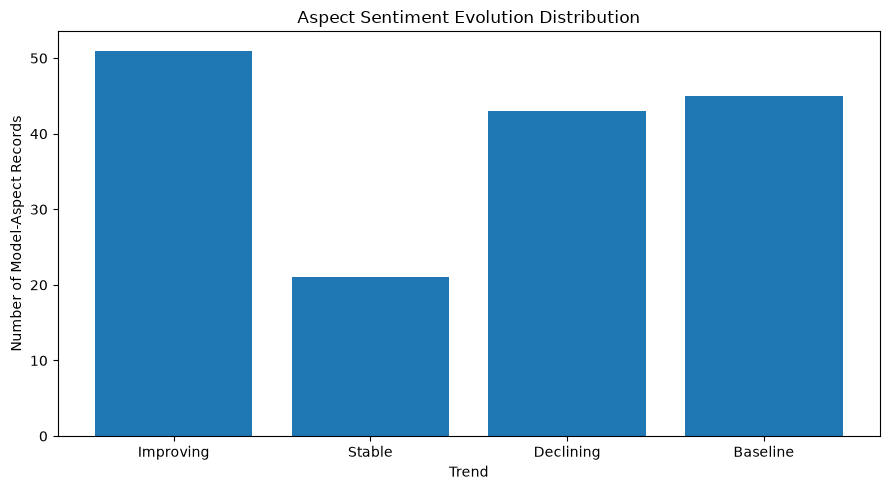

In [55]:
# ============================================================
# EVOLUTION TREND DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

trend_counts = (
    evolution_profile["trend"]
    .value_counts()
    .reindex(
        ["Improving", "Stable", "Declining", "Baseline"]
    )
)

plt.figure(figsize=(9, 5))

plt.bar(
    trend_counts.index,
    trend_counts.values
)

plt.title("Aspect Sentiment Evolution Distribution")
plt.xlabel("Trend")
plt.ylabel("Number of Model-Aspect Records")

plt.tight_layout()
plt.show()

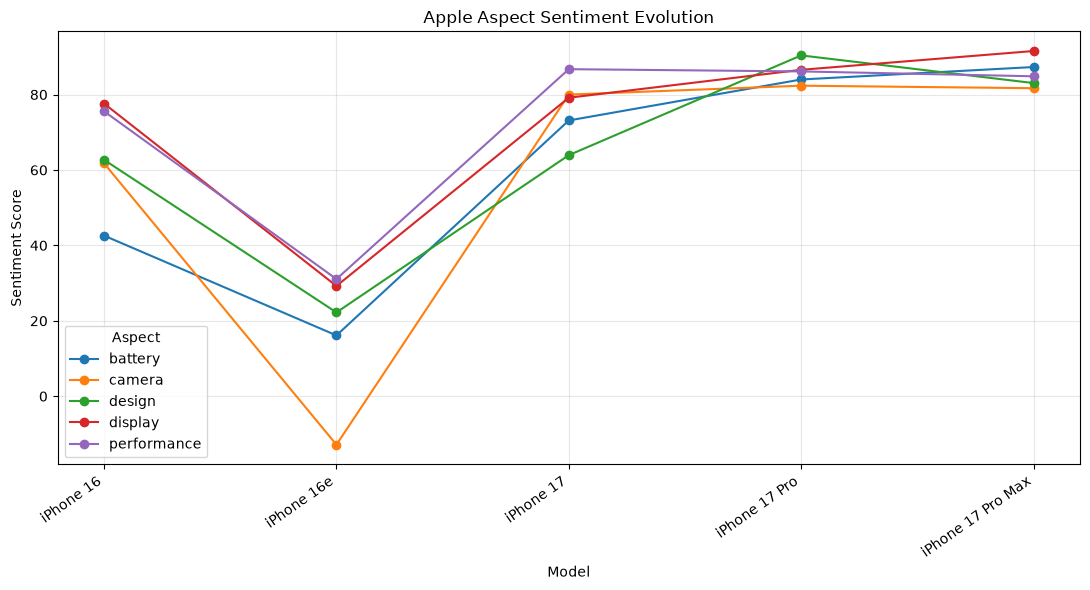

In [56]:
# ============================================================
# APPLE ASPECT SENTIMENT EVOLUTION
# ============================================================

apple_evolution = evolution_profile[
    evolution_profile["brand"] == "Apple"
]

plt.figure(figsize=(11, 6))

for aspect in sorted(
    apple_evolution["aspect"].unique()
):

    aspect_data = (
        apple_evolution[
            apple_evolution["aspect"] == aspect
        ]
        .sort_values("model_order")
    )

    plt.plot(
        aspect_data["model"],
        aspect_data["sentiment_score"],
        marker="o",
        label=aspect
    )

plt.title(
    "Apple Aspect Sentiment Evolution"
)

plt.xlabel("Model")
plt.ylabel("Sentiment Score")

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    title="Aspect"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [57]:
# ============================================================
# BIGGEST EVOLUTION CHANGES
# ============================================================

biggest_changes = (
    evolution_profile[
        evolution_profile["trend"] != "Baseline"
    ]
    .copy()
)

biggest_changes["absolute_change"] = (
    biggest_changes["sentiment_change"]
    .abs()
)

biggest_changes = (
    biggest_changes
    .sort_values(
        "absolute_change",
        ascending=False
    )
)

print("===== BIGGEST SENTIMENT CHANGES =====")

display(
    biggest_changes[
        [
            "brand",
            "model",
            "aspect",
            "sentiment_score",
            "sentiment_change",
            "trend"
        ]
    ].head(20)
)

===== BIGGEST SENTIMENT CHANGES =====


,brand,model,aspect,sentiment_score,sentiment_change,trend
49,Motorola,Motorola Edge 60 Pro,camera,43.103448,93.828086,Improving
7,Apple,iPhone 17,camera,80.000000,92.857143,Improving
128,Samsung,Galaxy A56 5G,camera,-9.090909,-92.167832,Declining
58,Motorola,Motorola Edge 60 Pro,performance,64.102564,86.432661,Improving
55,Motorola,Motorola Edge 60 Pro,display,63.492063,85.409872,Improving
47,Motorola,Razr 60 Ultra,battery,-7.843137,-81.280637,Declining
76,OPPO,Find X8 Pro,battery,68.627451,81.127451,Improving
52,Motorola,Motorola Edge 60 Pro,design,68.000000,78.000000,Improving
6,Apple,iPhone 16e,camera,-12.857143,-74.621849,Declining
149,Xiaomi,Xiaomi 15,camera,70.833333,74.059140,Improving


In [58]:
# ============================================================
# SAVE FINAL EVOLUTION DATA
# ============================================================

EVOLUTION_PATH = (
    "../data/processed/evolution_analysis.csv"
)

evolution_profile.to_csv(
    EVOLUTION_PATH,
    index=False
)

print("===== EVOLUTION DATA SAVED =====")
print("File:", EVOLUTION_PATH)
print("Rows:", len(evolution_profile))

===== EVOLUTION DATA SAVED =====
File: ../data/processed/evolution_analysis.csv
Rows: 160


## Conflict Detector

In [59]:
# ============================================================
# IMPORT CONFLICT DETECTOR
# ============================================================

from src.conflict_detector import (
    create_phone_aspect_profile,
    detect_aspect_conflicts,
    detect_review_level_conflicts,
    summarize_conflicts
)

print("Conflict Detector imported successfully.")

Conflict Detector imported successfully.


In [60]:
# ============================================================
# CREATE PHONE-ASPECT PROFILE FOR CONFLICT ANALYSIS
# ============================================================

conflict_profile = create_phone_aspect_profile(
    full_absa_results
)

print("===== CONFLICT PROFILE =====")
print(
    "Phone-aspect records:",
    len(conflict_profile)
)

display(
    conflict_profile.head(20)
)

===== CONFLICT PROFILE =====
Phone-aspect records: 160


,brand,model,aspect,mention_count,positive_pct,neutral_pct,negative_pct,avg_confidence,sentiment_score
0,Apple,iPhone 16,battery,54,48.148148,46.296296,5.555556,0.868661,42.592593
1,Apple,iPhone 16,camera,68,63.235294,35.294118,1.470588,0.862058,61.764706
2,Apple,iPhone 16,design,67,62.686567,37.313433,0.000000,0.879763,62.686567
3,Apple,iPhone 16,display,67,77.611940,22.388060,0.000000,0.916780,77.611940
4,Apple,iPhone 16,performance,90,75.555556,24.444444,0.000000,0.852487,75.555556
5,Apple,iPhone 16e,battery,62,41.935484,32.258065,25.806452,0.901720,16.129032
6,Apple,iPhone 16e,camera,70,14.285714,58.571429,27.142857,0.852348,-12.857143
7,Apple,iPhone 16e,design,63,31.746032,58.730159,9.523810,0.847776,22.222222
8,Apple,iPhone 16e,display,65,43.076923,43.076923,13.846154,0.909183,29.230769
9,Apple,iPhone 16e,performance,103,35.922330,59.223301,4.854369,0.803030,31.067961


In [61]:
# ============================================================
# DETECT PHONE-LEVEL ASPECT CONFLICTS
# ============================================================

phone_conflicts = detect_aspect_conflicts(
    conflict_profile,
    positive_threshold=50,
    negative_threshold=25
)

print("===== PHONE-LEVEL ASPECT CONFLICTS =====")

print(
    "Conflicts detected:",
    len(phone_conflicts)
)

display(
    phone_conflicts.head(30)
)

===== PHONE-LEVEL ASPECT CONFLICTS =====
Conflicts detected: 11


,brand,model,aspect_positive,positive_pct,aspect_negative,negative_pct,conflict_strength
0,Motorola,Moto G Power 2025,battery,77.142857,camera,59.420290,68.281573
1,Motorola,Moto G Power 2025,battery,77.142857,performance,37.864078,57.503467
2,Motorola,Moto G Power 2025,battery,77.142857,display,36.986301,57.064579
3,Nothing,Phone 2a Plus,battery,68.421053,camera,40.298507,54.359780
4,Motorola,Moto G Power 2025,battery,77.142857,design,25.000000,51.071429
5,Xiaomi,Redmi Note 14 Pro+,battery,67.213115,camera,25.806452,46.509783
6,Motorola,Razr 60 Ultra,display,54.716981,battery,37.254902,45.985942
7,Motorola,Razr 60 Ultra,design,52.941176,battery,37.254902,45.098039
8,Samsung,Galaxy Z Flip7,display,53.623188,battery,34.482759,44.052974
9,Samsung,Galaxy Z Flip7,design,53.061224,battery,34.482759,43.771992


In [62]:
# ============================================================
# DETECT REVIEW-LEVEL SENTIMENT CONFLICTS
# ============================================================

review_conflicts = detect_review_level_conflicts(
    full_absa_results
)

print("===== REVIEW-LEVEL CONFLICTS =====")

print(
    "Conflicting reviews:",
    len(review_conflicts)
)

display(
    review_conflicts.head(30)
)

===== REVIEW-LEVEL CONFLICTS =====
Conflicting reviews: 399


,review_id,aspect_positive,aspect_negative
0,49,camera,battery
1,49,performance,battery
2,52,display,battery
3,136,battery,display
4,143,performance,camera
5,143,display,camera
6,156,battery,camera
7,156,battery,performance
8,156,battery,design
9,156,battery,display


In [63]:
# ============================================================
# CONFLICT SUMMARY
# ============================================================

conflict_summary = summarize_conflicts(
    review_conflicts
)

print("===== MOST COMMON REVIEW-LEVEL CONFLICTS =====")

display(
    conflict_summary.head(20)
)

===== MOST COMMON REVIEW-LEVEL CONFLICTS =====


,aspect_positive,aspect_negative,conflict_count
0,battery,camera,44
13,display,camera,37
17,performance,camera,33
16,performance,battery,28
2,battery,display,27
12,display,battery,27
9,design,camera,25
3,battery,performance,22
15,display,performance,22
4,camera,battery,21


In [64]:
# ============================================================
# SAVE CONFLICT ANALYSIS
# ============================================================

PHONE_CONFLICT_PATH = (
    "../data/processed/phone_aspect_conflicts.csv"
)

REVIEW_CONFLICT_PATH = (
    "../data/processed/review_aspect_conflicts.csv"
)

SUMMARY_PATH = (
    "../data/processed/conflict_summary.csv"
)


phone_conflicts.to_csv(
    PHONE_CONFLICT_PATH,
    index=False
)

review_conflicts.to_csv(
    REVIEW_CONFLICT_PATH,
    index=False
)

conflict_summary.to_csv(
    SUMMARY_PATH,
    index=False
)


print("===== CONFLICT ANALYSIS SAVED =====")

print(
    "Phone conflicts:",
    PHONE_CONFLICT_PATH
)

print(
    "Review conflicts:",
    REVIEW_CONFLICT_PATH
)

print(
    "Conflict summary:",
    SUMMARY_PATH
)

===== CONFLICT ANALYSIS SAVED =====
Phone conflicts: ../data/processed/phone_aspect_conflicts.csv
Review conflicts: ../data/processed/review_aspect_conflicts.csv
Conflict summary: ../data/processed/conflict_summary.csv


In [65]:
# ============================================================
# CONFLICTS BY PHONE
# ============================================================

conflicts_by_phone = (
    review_conflicts
    .merge(
        full_absa_results[
            ["review_id", "brand", "model"]
        ].drop_duplicates("review_id"),
        on="review_id",
        how="left"
    )
    .groupby(
        ["brand", "model"]
    )
    .size()
    .reset_index(
        name="conflict_count"
    )
    .sort_values(
        "conflict_count",
        ascending=False
    )
)

print("===== PHONES WITH MOST SENTIMENT CONFLICTS =====")

display(
    conflicts_by_phone.head(15)
)

===== PHONES WITH MOST SENTIMENT CONFLICTS =====


,brand,model,conflict_count
6,Motorola,Moto G Power 2025,54
10,Nothing,Phone 2a Plus,38
1,Apple,iPhone 16e,37
22,Xiaomi,Redmi Note 14 Pro+,28
20,Samsung,Galaxy A56 5G,26
21,Samsung,Galaxy Z Flip7,22
8,Motorola,Razr 60 Ultra,21
11,Nothing,Phone 3a Pro,21
5,Google,Pixel 9a,20
12,OPPO,Find N5,20


In [66]:
# ============================================================
# MOST COMMON ASPECT CONFLICT PAIRS
# ============================================================

aspect_conflict_summary = (
    review_conflicts
    .groupby(
        [
            "aspect_positive",
            "aspect_negative"
        ]
    )
    .size()
    .reset_index(
        name="conflict_count"
    )
    .sort_values(
        "conflict_count",
        ascending=False
    )
)

print("===== MOST COMMON ASPECT CONFLICT PAIRS =====")

display(
    aspect_conflict_summary.head(15)
)

===== MOST COMMON ASPECT CONFLICT PAIRS =====


,aspect_positive,aspect_negative,conflict_count
0,battery,camera,44
13,display,camera,37
17,performance,camera,33
16,performance,battery,28
2,battery,display,27
12,display,battery,27
9,design,camera,25
3,battery,performance,22
15,display,performance,22
4,camera,battery,21


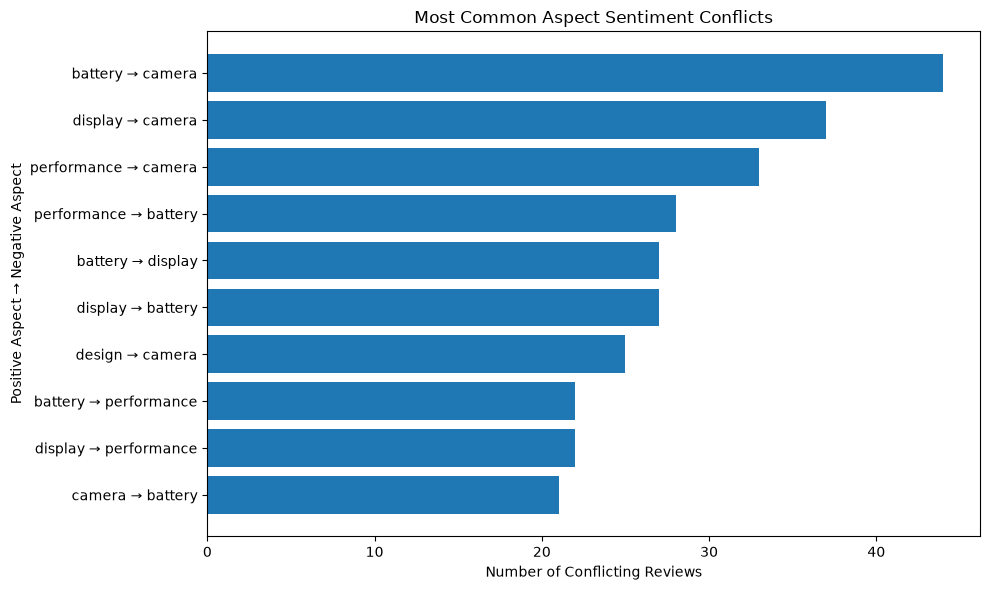

In [67]:
# ============================================================
# TOP ASPECT CONFLICT PAIRS
# ============================================================

top_conflicts = (
    aspect_conflict_summary
    .head(10)
    .copy()
)

top_conflicts["pair"] = (
    top_conflicts["aspect_positive"]
    + " → "
    + top_conflicts["aspect_negative"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_conflicts["pair"][::-1],
    top_conflicts["conflict_count"][::-1]
)

plt.title(
    "Most Common Aspect Sentiment Conflicts"
)

plt.xlabel("Number of Conflicting Reviews")
plt.ylabel("Positive Aspect → Negative Aspect")

plt.tight_layout()
plt.show()

In [69]:
# ============================================================
# SAVE CONFLICT SUMMARIES
# ============================================================

CONFLICT_PHONE_PATH = (
    "../data/processed/conflicts_by_phone.csv"
)

CONFLICT_ASPECT_PATH = (
    "../data/processed/aspect_conflict_summary.csv"
)

conflicts_by_phone.to_csv(
    CONFLICT_PHONE_PATH,
    index=False
)

aspect_conflict_summary.to_csv(
    CONFLICT_ASPECT_PATH,
    index=False
)

print("===== CONFLICT SUMMARIES SAVED =====")
print(
    "Phone summary:",
    CONFLICT_PHONE_PATH
)

print(
    "Aspect summary:",
    CONFLICT_ASPECT_PATH
)

===== CONFLICT SUMMARIES SAVED =====
Phone summary: ../data/processed/conflicts_by_phone.csv
Aspect summary: ../data/processed/aspect_conflict_summary.csv
